In [32]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from osgeo import gdal
import xarray as xr
from scipy.io import loadmat
from scipy.interpolate import interp1d, interp2d, NearestNDInterpolator, RegularGridInterpolator

#Interpolating data to fit points so that therre are even spaces, or linearly interpolate missing points
#In 2D, regularised vs irregular grids (triangular pattern) (we only do regularised grids (tiles))
#Define who fine the grid is

In [4]:
def xyz_geotiff(img):
    band = img.GetRasterBand(1)
    z = np.flipud(band.ReadAsArray()).T
    width = img.RasterXSize
    height = img.RasterYSize
    gt = img.GetGeoTransform()
    minx = gt[0]
    miny = gt[3] + width*gt[4] + height*gt[5]
    maxx = gt[0] + width*gt[1] + height*gt[2]
    maxy = gt[3]
    lon = np.linspace(minx,maxx,width)
    lat = np.linspace(miny,maxy,height)
    return lon,lat,z
#Takes a geotiff image and loads it in

def transect2dxyz(p0,p1,x,y,z):
    #Interpolates a transect on a grid
    # p0 is the point the line starts on
    # finishes on p1
    #x and y are grid coordinates with z is the variable field of the grid
    # step along line is equal to x spacing
    tempinterpolator = RegularGridInterpolator((x,y),z)
    #builds interpolator (from scipy)
    linelength = ((p1[0]-p0[0])**2+(p1[1]-p0[1])**2)**0.5
    #pythag between A and B (p1 and p0) for line length
    spoints = np.arange(0,linelength,np.diff(x)[0])
    #create regular points along the line, same spacing as the x interval to prevent over sampling
    xpoints = np.cos(np.arctan2(p1[1]-p0[1],p1[0]-p0[0]))*spoints+p0[0]
    ypoints = np.sin(np.arctan2(p1[1]-p0[1],p1[0]-p0[0]))*spoints+p0[1]
    zpoints = tempinterpolator((xpoints,ypoints))
    return spoints,xpoints,ypoints,zpoints


def get_regulargrid(x,y,z,npoints):
    if type(npoints)==tuple:
        if len(npoints)==2:
            x_grid = np.linspace(np.min(x),np.max(x),npoints[0])
            y_grid = np.linspace(np.min(y),np.max(y),npoints[1])
        else:
            return 'error: npoints as tuple must have len(npoints)==2'
    elif type(npoints)==int:
        x_grid = np.linspace(np.min(x),np.max(x),npoints)
        y_grid = np.linspace(np.min(y),np.max(y),npoints)        
    else:
        return 'error: npoints must be an int or a tuple of length 2'
    finterp2d = NearestNDInterpolator(list(zip(x, y)),z)
    #nearest neighbour interpolator
    X_grid,Y_grid = np.meshgrid(x_grid,y_grid)
    z_grid = finterp2d(X_grid,Y_grid)
    return x_grid,y_grid,z_grid

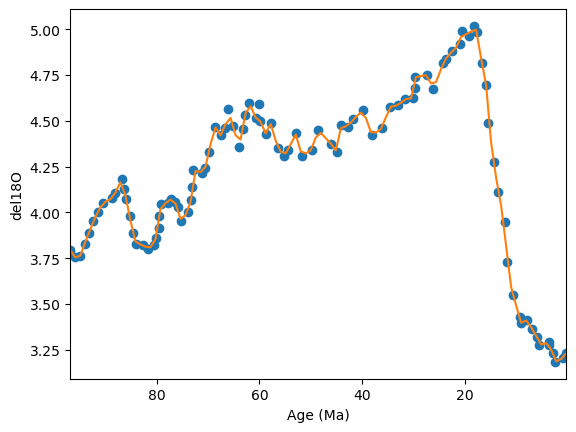

In [36]:
cols_names= ['Age MA', 'del18O']
df = pd.read_csv("ICE.csv",header=None, names=cols_names)
subdf = df.head(100)
AgeMA = subdf['Age MA']
DEL = subdf['del18O']
#plt.scatter(AgeMA, DEL) #Plots the scatter
plt.xlim(max(AgeMA), min(AgeMA))
plt.xlabel('Age (Ma)')
plt.ylabel('del18O')

#npoints = 100
#tempx,tempy = get_regulargrid(AgeMA,DEL,npoints)
#p0 = [df.iat[0, 0],df.iat[0, 1]]
#p1 = [df.iat[100, 0],df.iat[100, 1]]
#spoints,lonpoints,latpoints = transect2dxyz(p0,p1,tempx,tempy)

f = interp1d(AgeMA, DEL)
xnew = np.linspace(np.min(AgeMA), np.max(AgeMA), num=len(AgeMA), endpoint=True)
plt.plot(AgeMA, DEL, 'o', xnew, f(xnew), '-')